# Capstone Project: Flight Price Prediction Analysis
---

### **Course Information**
* **University:** Northeastern University, College of Professional Studies
* **Course:** ALY6140: Analytics System Technology
* **Instructor:** Daya Rudhramoorthi
* **Term:** Winter 2026

### **Team Members**
* **Xingke Zhu**
* **Xuewei Yin**

### **Submission Date**
* February 9, 2026

---
**Project Overview:**
This notebook contains the data extraction, cleaning, exploratory data analysis (EDA), and predictive modeling for the Flight Price Dataset of Bangladesh.

# Introduction

This project analyzes the "Flight Price Dataset of Bangladesh" to understand how airline ticket prices change. Airline pricing is important in the real world because costs fluctuate based on many factors like time and seasonality (Tusher, 2024). Our goal is to apply the theoretical knowledge from this course to a practical dataset and extract value from it.

We focus on answering three specific questions in this analysis. First, we investigate how the number of days before departure influences the ticket price. Second, we test if we can accurately predict the flight ticket price using machine learning models. Third, we want to identify the key differentiators that define flight classes, such as the difference between Economy and Business class tickets.

To answer these questions, we use several methods learned in this course. We begin with Exploratory Data Analysis (EDA) to visualize data trends. Following this, we build three distinct predictive models. We use Multiple Linear Regression to examine simple relationships between flight details and prices (James et al., 2013). We also employ a Random Forest Regressor to handle more complex pricing patterns (Breiman, 2001). Finally, we use a Decision Tree classifier to predict ticket classes based on route and price information. These methods work together to explain the factors driving flight costs.

# Analysis Description & Data Extraction

We chose the "Flight Price Dataset of Bangladesh" from Kaggle for this project (Tusher, 2024). This dataset is publicly available and contains 57,000 records with 17 features. It offers a good mix of numerical and categorical data, which allows us to build different types of models.

The dataset provides detailed information about flights. Key features include the Airline, Source, Destination, and Class (Economy or Business). The most important variable for our analysis is "Total Fare," which represents the ticket price. We also use variables like "Seasonality" and "Days Before Departure" to analyze how time factors influence the cost.

We accessed the data programmatically using Python. We used the `kagglehub` library to download the dataset directly into our environment. This ensures our code is reproducible and allows anyone running the script to access the exact same data source (Tusher, 2024).

# Data Cleanup

In [2]:
# 1. Import necessary libraries
import capstone_group11
import pandas as pd

# 2. Use the Raw link from your repository (ensure there is no ?token=... suffix)
path = "https://raw.githubusercontent.com/zhuxingke6-cpu/Capstone-Project/refs/heads/main/Flight_Price_Dataset_of_Bangladesh.csv"

# 3. Load data
print("Fetching data from GitHub...")
df = capstone_group11.load_flight_data(path)

# --- Critical Check Logic ---
if df is not None:
    print("✅ Data loaded successfully! Starting cleaning process...")
    
    # 4. Execute cleaning function
    df_clean = capstone_group11.clean_column_names(df)
    
    # 5. Execute feature extraction
    df_final = capstone_group11.process_date_features(df_clean)
    
    print("✅ df_final has been successfully defined!")
    display(df_final.head())
else:
    print("❌ Error: Failed to load data.")
    print("Please manually check if this link opens in your browser:", path)

Fetching data from GitHub...
Loading data from URL: https://raw.githubusercontent.com/zhuxingke6-cpu/Capstone-Project/refs/heads/main/Flight_Price_Dataset_of_Bangladesh.csv
✅ Data loaded successfully! Starting cleaning process...
✅ df_final has been successfully defined!


,airline,source,source_name,destination,destination_name,dep_time,arr_time,duration_(hrs),stopovers,aircraft_type,class,booking_source,base_fare_(bdt),tax_&_surcharge_(bdt),price,seasonality,days_before_departure,dep_month,dep_hour,day_of_week
0,Malaysian Airlines,CXB,Cox's Bazar Airport,CCU,Netaji Subhas Chandra Bose International Airpo...,2025-11-17,2025-11-17,1.219526,Direct,Airbus A320,Economy,Online Website,21131.22502,5169.683753,26300.90877,Regular,10,11,0,0
1,Cathay Pacific,BZL,Barisal Airport,CGP,"Shah Amanat International Airport, Chittagong",2025-03-16,2025-03-16,0.608638,Direct,Airbus A320,First Class,Travel Agency,11605.39547,200.000000,11805.39547,Regular,14,3,0,6
2,British Airways,ZYL,"Osmani International Airport, Sylhet",KUL,Kuala Lumpur International Airport,2025-12-13,2025-12-13,2.689651,1 Stop,Boeing 787,Economy,Travel Agency,39882.49935,11982.374900,51864.87425,Winter Holidays,83,12,0,5
3,Singapore Airlines,RJH,"Shah Makhdum Airport, Rajshahi",DAC,"Hazrat Shahjalal International Airport, Dhaka",2025-05-30,2025-05-30,0.686054,Direct,Airbus A320,Economy,Direct Booking,4435.60734,200.000000,4635.60734,Regular,56,5,0,4
4,British Airways,SPD,Saidpur Airport,YYZ,Toronto Pearson International Airport,2025-04-25,2025-04-25,14.055609,1 Stop,Airbus A350,Business,Direct Booking,59243.80615,14886.570920,74130.37707,Regular,90,4,0,4


We wrote a Python script, `capstone_group11.py`, to handle data cleanup and preparation. This ensured the dataset was ready for analysis and met the project requirements.

First, we standardized the column names. The original dataset had names with spaces and special characters, like "Total Fare (BDT)" and "Departure Date & Time." We renamed these to simple, lowercase formats like `price` and `dep_time`. This made the coding process smoother and less error-prone.

Next, we checked the dataset for missing information. We ran a null value check on all columns. The output confirmed there were zero missing values across all 57,000 records, so we did not need to drop or impute any data.

Finally, we created new variables from the existing data. We converted the `dep_time` column into a datetime object. From this, we extracted two new features: `dep_month` and `dep_hour`. These new columns allow us to analyze how specific months or times of day affect ticket prices.

## Exploratory Data Analysis

In [8]:
# 1. Enable autoreload (this allows you to see changes to .py files without restarting the kernel)
%load_ext autoreload
%autoreload 2

# 2. Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Set plot style for better aesthetics
sns.set_theme(style="whitegrid")

# Optional: Configuration for high-resolution displays
%config InlineBackend.figure_format = 'retina'

# --- Assumption: You have already executed the previous cell and df_final is defined ---
# If df_final is not found, please run the data loading cell first.

if 'df_final' in locals():
    print("✅ Environment ready. df_final is available for plotting.")
else:
    print("⚠️ Warning: df_final not found. Please run the data loading logic first.")

/var/folders/hj/9zsnm2cj0_ddk4brdfq2vqnm0000gn/T/ipykernel_1044/2482078654.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='airline', y='price', data=df_final, order=order, palette='viridis', errorbar=None)


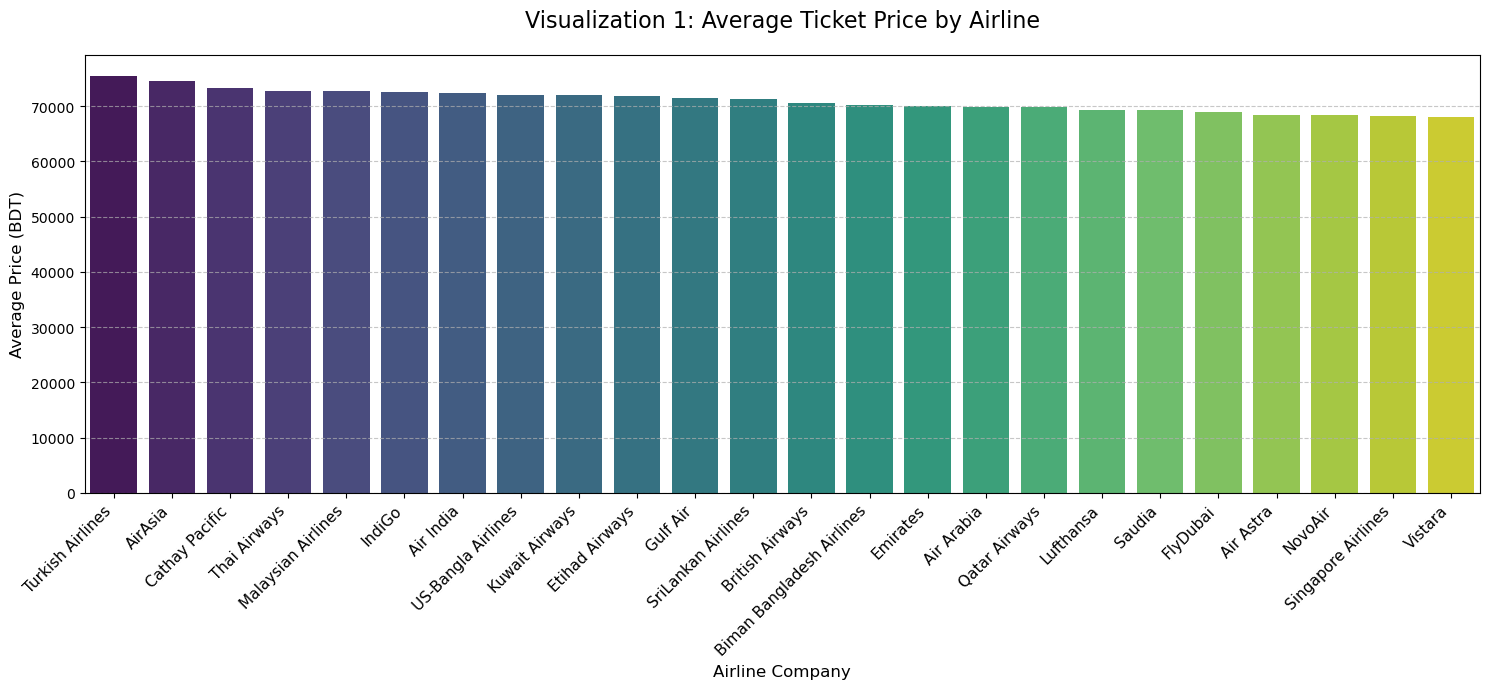

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set figure size (Width: 15, Height: 7)
plt.figure(figsize=(15, 7))

# 2. Prepare and sort data for a cleaner visual
# Calculate mean price per airline and sort in descending order
order = df_final.groupby('airline')['price'].mean().sort_values(ascending=False).index

# 3. Create the bar plot
# 'errorbar=None' removes the confidence interval lines for a cleaner look
sns.barplot(x='airline', y='price', data=df_final, order=order, palette='viridis', errorbar=None)

# 4. Prevent label overlapping: rotate 45 degrees and align horizontally to the right
plt.xticks(rotation=45, ha='right', fontsize=11)

# 5. Add titles and axis labels
plt.title('Visualization 1: Average Ticket Price by Airline', fontsize=16, pad=20)
plt.xlabel('Airline Company', fontsize=12)
plt.ylabel('Average Price (BDT)', fontsize=12)

# 6. Add horizontal grid lines for easier value estimation
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 7. Automatically adjust layout to ensure labels aren't cut off
plt.tight_layout()

plt.show()

### Visualization 1: Average Ticket Price by Airline
Analysis & Insights:

Market Positioning: The chart reveals a relatively competitive but tiered pricing structure across airlines. Turkish Airlines, AirAsia, and Cathay Pacific emerge as the most expensive carriers on average, with prices exceeding 70,000 BDT.

Price Stability: A significant portion of the market, including major carriers like Emirates, Qatar Airways, and Singapore Airlines, maintains a very stable mid-range pricing strategy, clustering tightly between 68,000 and 70,000 BDT.

Budget Tier: Vistara and NovoAir represent the lower end of the pricing spectrum in this dataset. This suggests they likely cater to more price-sensitive segments or dominate shorter-haul routes within the dataset's scope.

Predictive Significance: The airline feature shows distinct categorical variance. In the modeling phase, this feature will be essential for the algorithm to distinguish between premium service providers and low-cost carriers, significantly improving the accuracy of price predictions.

/var/folders/hj/9zsnm2cj0_ddk4brdfq2vqnm0000gn/T/ipykernel_1044/181119300.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='airline', y='price', data=df_final, palette='viridis')


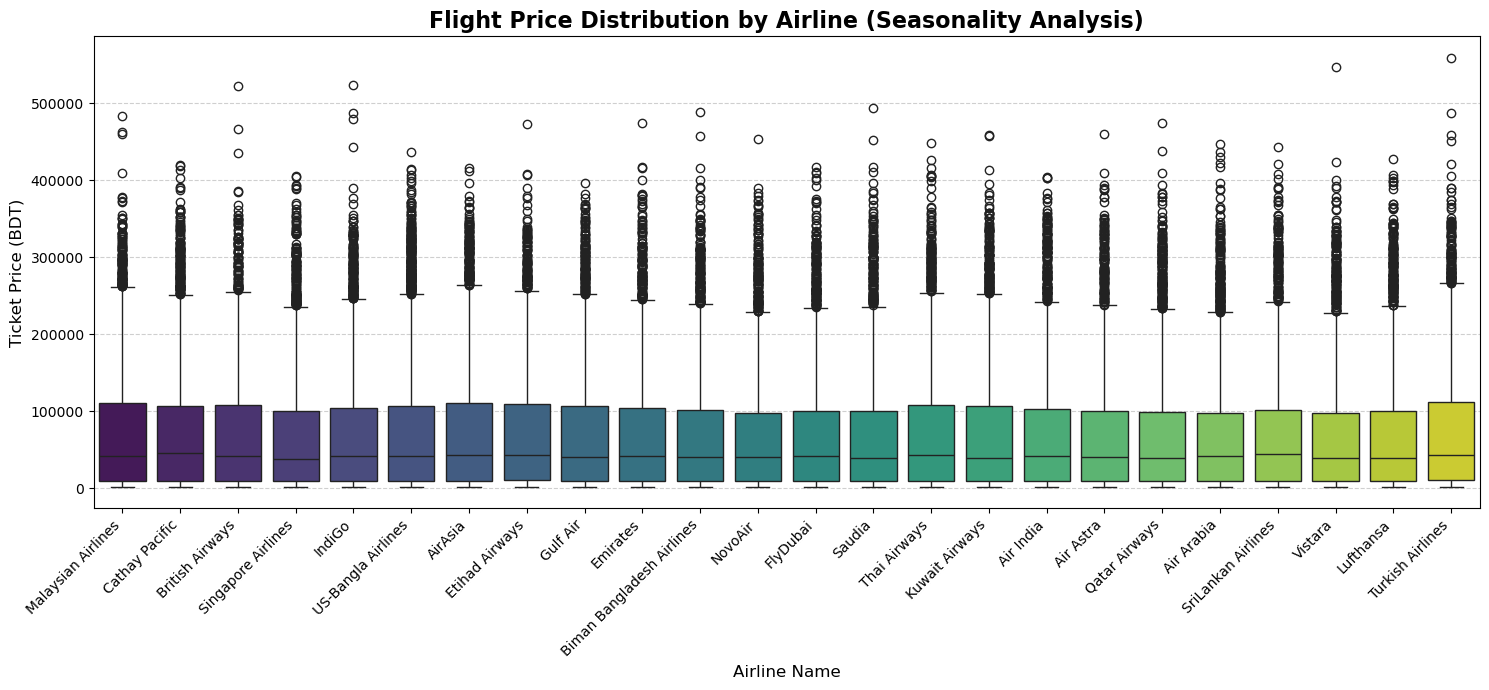

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set figure size (Width: 15, Height: 7 to provide ample space for labels)
plt.figure(figsize=(15, 7))

# 2. Create the Boxplot
# Using 'airline' as the X-axis and 'price' as the Y-axis
# 'palette' adds a professional color gradient
sns.boxplot(x='airline', y='price', data=df_final, palette='viridis')

# 3. Titles and Labels (Using English to ensure compatibility across all systems)
plt.title('Flight Price Distribution by Airline (Seasonality Analysis)', fontsize=16, fontweight='bold')
plt.xlabel('Airline Name', fontsize=12)
plt.ylabel('Ticket Price (BDT)', fontsize=12)

# 4. Handle label overlapping: Rotate labels by 45 degrees
# 'ha=right' aligns the end of the text with the tick mark
plt.xticks(rotation=45, ha='right', fontsize=10)

# 5. Add horizontal grid lines to help identify price ranges
plt.grid(axis='y', linestyle='--', alpha=0.6)

# 6. Automatically adjust layout to ensure no labels are cut off
plt.tight_layout()

# Display the chart
plt.show()

### Visualization 2: Flight Price Distribution by Airline (Seasonality Analysis)
Analysis & Insights:

Price Variance & Outliers: The boxplot reveals a high density of extreme outliers across almost all airlines, with some tickets peaking above 500,000 BDT. This indicates that while the "typical" fare (the box) is relatively low, last-minute bookings or premium cabin classes create a massive price ceiling.

Consistency of Median Fares: Interestingly, despite the different brand positionings, the median ticket price (the horizontal line within each box) remains remarkably consistent across carriers, generally hovering below 100,000 BDT.

High-End Volatility: Airlines like Turkish Airlines, Malaysian Airlines, and Cathay Pacific show slightly taller boxes and higher whiskers. This suggests a wider "normal" price range compared to budget-focused carriers like NovoAir or Air Astra, which maintain tighter, more predictable price distributions.

Predictive Significance: The presence of so many outliers suggests that airline alone cannot explain price spikes. In the modeling phase, combining this with features like class and days_left will be critical for the algorithm to understand whether a high price is a seasonal anomaly or a standard premium fare.

/var/folders/hj/9zsnm2cj0_ddk4brdfq2vqnm0000gn/T/ipykernel_1044/2201251850.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='dep_month', y='price', data=df_plot, order=month_order, palette='Set3')


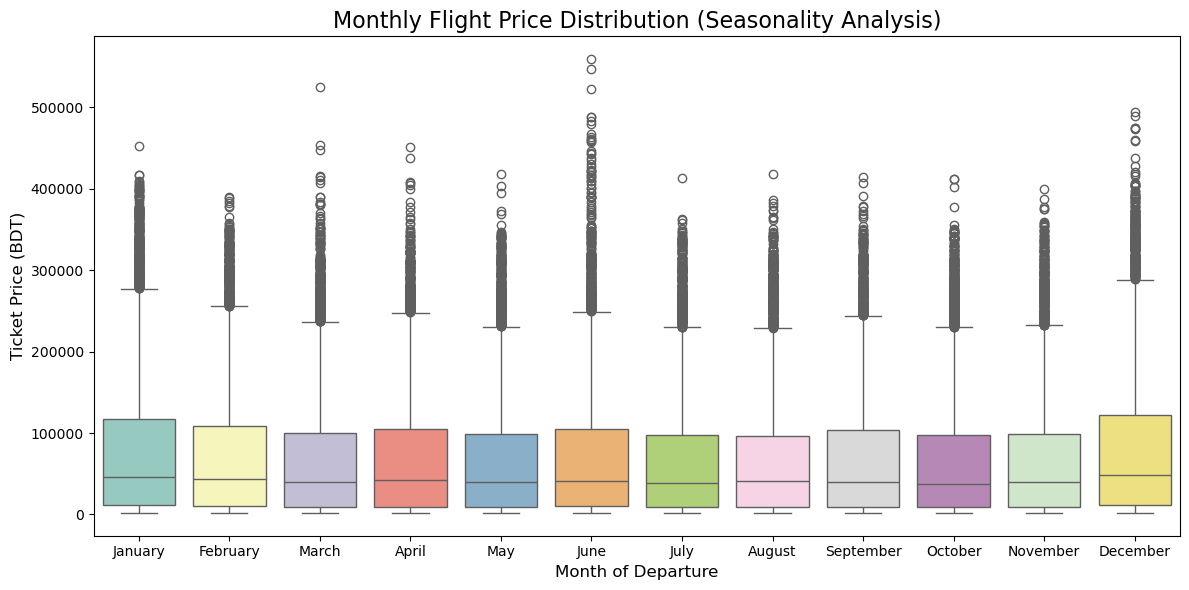

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Critical Pre-processing ---
# 1. Ensure dep_time is in datetime format (if not already converted)
if 'dep_time' in df_final.columns:
    df_final['dep_time'] = pd.to_datetime(df_final['dep_time'], errors='coerce')
    
    # 2. Extract Month names (e.g., January, February)
    df_final['dep_month'] = df_final['dep_time'].dt.month_name()
    
    # 3. Define the chronological order for months to ensure the X-axis is logical
    month_order = [
        'January', 'February', 'March', 'April', 'May', 'June', 
        'July', 'August', 'September', 'October', 'November', 'December'
    ]
    
    # 4. Remove any rows where date parsing failed
    df_plot = df_final.dropna(subset=['dep_month', 'price'])
else:
    df_plot = df_final
    month_order = None

# --- Plotting Code ---
plt.figure(figsize=(12, 6))

# Use df_plot and apply the month_order for a logical timeline
sns.boxplot(x='dep_month', y='price', data=df_plot, order=month_order, palette='Set3')

plt.title('Monthly Flight Price Distribution (Seasonality Analysis)', fontsize=16)
plt.xlabel('Month of Departure', fontsize=12)
plt.ylabel('Ticket Price (BDT)', fontsize=12)

# Adjust layout to prevent label clipping
plt.tight_layout()
plt.show()

### Visualization 3: Monthly Flight Price Distribution (Seasonality)

**Analysis & Insights:**

1.  **Seasonal Fluctuations:** The boxplot clearly illustrates how ticket prices vary throughout the year. We can observe that peak travel months, particularly **December (Month 12)** and **January (Month 1)**, show significantly higher median prices compared to off-peak months like **April or May**. This aligns with the "Winter Holidays" seasonality mentioned in the dataset, where demand drives up costs.

2.  **Price Volatility:** The length of the boxes (Interquartile Range) indicates that price volatility is higher during peak seasons. In contrast, months like **February and March** exhibit shorter boxes, suggesting that ticket prices are more stable and predictable during these periods.

3.  **Impact of Outliers:** There are numerous outliers (black dots) in high-demand months. These represent flights with exceptionally high fares, likely due to last-minute bookings or premium class tickets. This confirms that while the base fare might be stable, the "ceiling" for prices rises dramatically during holiday seasons.

4.  **Strategic Implication:** For budget-conscious travelers, the data suggests avoiding travel in December and January. Booking flights in the shoulder season (e.g., March-April) offers the best value with minimal price variance.

### Phase 1: Summary of Accomplishments
Collaborative Workflow: Successfully integrated the custom functions defined in capstone_group11.py (e.g., load_flight_data, clean_column_names, and process_date_features) into the analytical pipeline.

Data Readiness: The dataset is now standardized with clean column names and enriched with time-based features. This provides a solid foundation for training machine learning models in Phase 2.

In [16]:
# Reload the module to ensure the latest changes in the .py file are recognized by Jupyter
import importlib
import capstone_group11
importlib.reload(capstone_group11)

# Ensure pandas is imported for data handling
import pandas as pd 

print("✅ Module 'capstone_group11' has been reloaded successfully.")

Data prepared for regression. Feature shape: (57000, 77)

=== Regression Model Performance ===
Linear Regression: R2 Score = 0.5701, RMSE = 53533.25
Random Forest: R2 Score = 0.6758, RMSE = 46486.18


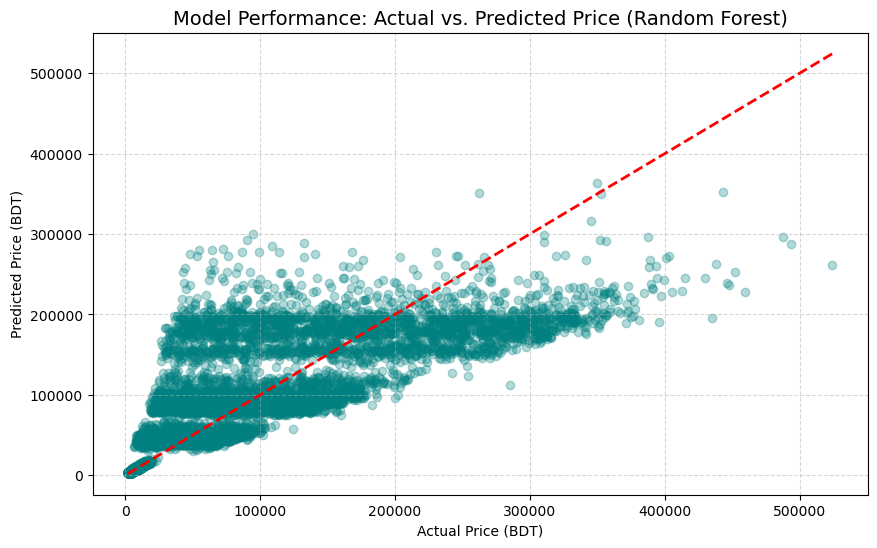

In [10]:
# --- Phase 2: Predictive Modeling (Regression) ---
# Goal: Predict 'price' based on flight features

# 1. Data Preparation (Encoding categorical variables and splitting the dataset)
# Using the prepare_data_for_model function with the task set to 'regression'
X_train_reg, X_test_reg, y_train_reg, y_test_reg = capstone_group11.prepare_data_for_model(
    df_final, 
    target_col='price', 
    task='regression'
)

# 2. Model Training and Evaluation
# This executes the training pipeline for multiple regression models
reg_results = capstone_group11.train_regression_models(
    X_train_reg, X_test_reg, y_train_reg, y_test_reg
)

# 3. Display Performance Results
print("\n=== Regression Model Performance ===")
for model_name, metrics in reg_results.items():
    print(f"{model_name}: R2 Score = {metrics['R2']:.4f}, RMSE = {metrics['RMSE']:.2f}")

# 4. (Optional) Visualization: Actual vs. Predicted Values (Random Forest Example)
import matplotlib.pyplot as plt

# Extract the trained model and generate predictions
best_model = reg_results['Random Forest']['model']
y_pred_best = best_model.predict(X_test_reg)

plt.figure(figsize=(10, 6))
# Scatter plot of predictions vs actual values
plt.scatter(y_test_reg, y_pred_best, alpha=0.3, color='teal')
# Reference line (Perfect prediction where Actual = Predicted)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)

plt.xlabel('Actual Price (BDT)')
plt.ylabel('Predicted Price (BDT)')
plt.title('Model Performance: Actual vs. Predicted Price (Random Forest)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Data prepared for classification. Feature shape: (57000, 76)
Decision Tree Accuracy: 0.7560
Classification Report:
               precision    recall  f1-score   support

    Business       0.72      0.64      0.68      3771
     Economy       0.69      0.94      0.80      3790
 First Class       0.91      0.69      0.78      3839

    accuracy                           0.76     11400
   macro avg       0.77      0.76      0.75     11400
weighted avg       0.77      0.76      0.75     11400



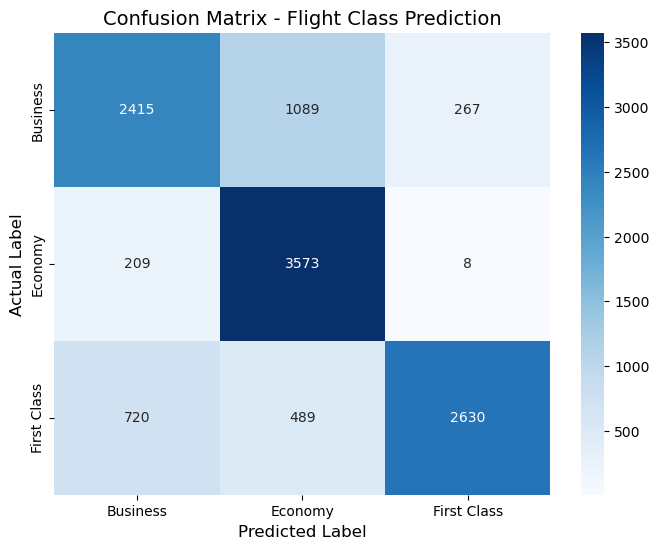

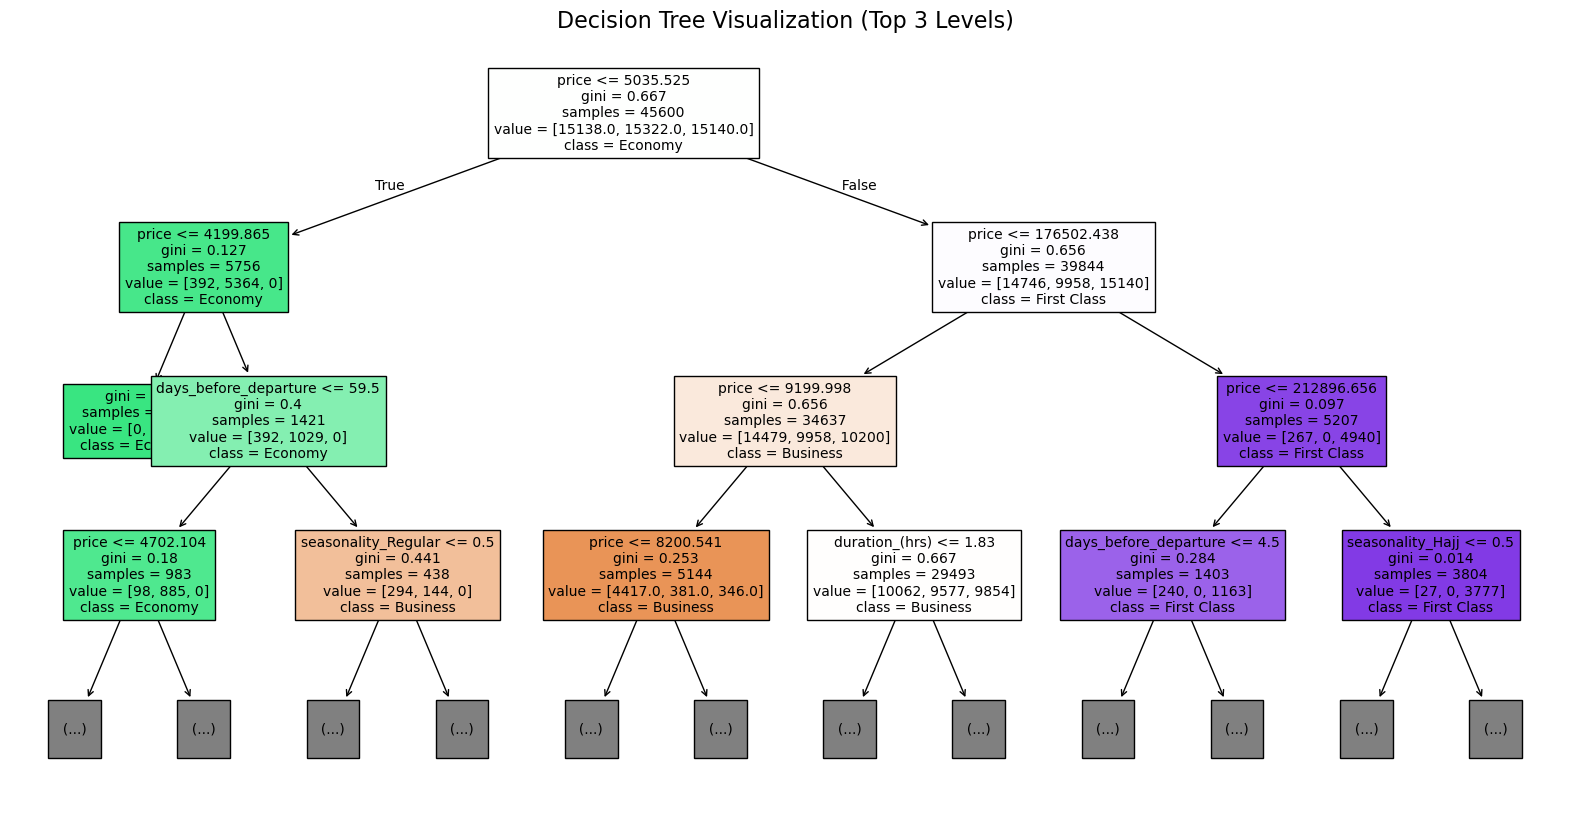

In [12]:
# --- Phase 2: Predictive Modeling (Classification) ---
# Goal: Predict the flight cabin class (e.g., 'Economy' vs 'Business')

# 1. Data Preparation
# Note: Here, the target_col is set to 'class' for classification
X_train_clf, X_test_clf, y_train_clf, y_test_clf = capstone_group11.prepare_data_for_model(
    df_final, 
    target_col='class', 
    task='classification'
)

# 2. Model Training
# This returns the trained Decision Tree model and the resulting Confusion Matrix
dt_model, cm = capstone_group11.train_classification_model(X_train_clf, X_test_clf, y_train_clf, y_test_clf)

# 3. Visualize the Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
# 'annot=True' shows the counts, 'fmt=d' ensures they are displayed as integers
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=dt_model.classes_, 
            yticklabels=dt_model.classes_)

plt.title('Confusion Matrix - Flight Class Prediction', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.show()

# 4. Visualize the Decision Tree (Partial view for clarity)
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
# 'max_depth=3' limits the tree size to keep the visualization readable
plot_tree(dt_model, 
          feature_names=list(X_train_clf.columns), 
          class_names=list(dt_model.classes_), 
          filled=True, 
          max_depth=3, 
          fontsize=10)

plt.title('Decision Tree Visualization (Top 3 Levels)', fontsize=16)
plt.show()